In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(os.getenv("DATABASE_URL"))

df = pd.read_sql("SELECT * FROM analytics.fact_orders", engine)

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,delivery_time_days,estimated_delivery_time_days,delay_days,is_late,has_review,has_delivery_date,distance_km,purchase_year,purchase_month,purchase_year_month
0,3814590ae0c00af31f205e41ebb9b270,e28fd47166be6c878520ec6039305379,delivered,2018-05-21 11:40:23,2018-05-21 15:32:01,2018-05-28 12:10:00,2018-06-06 11:45:30,2018-06-04,a42999dd3c67e6532a092dedaea1ea34,12241,...,16.0,13,2.0,1,1,1,71.046519,2018,5,2018-05
1,5619a43b2e52eacbfaafc5c569c1866d,61e4bd7aa14615235bfe015555cb2b97,delivered,2017-11-11 07:19:12,2017-11-11 07:30:19,2017-11-22 10:21:31,2017-12-01 20:33:45,2017-12-01,ed4293eca45bded8b970b1f7271c84d4,12570,...,20.0,19,0.0,0,1,1,388.147422,2017,11,2017-11
2,4c1b702493f9e6a8e7ab024bd34ba0d4,b60c51ace71de22be01c829273960649,delivered,2018-08-02 19:09:09,2018-08-02 19:43:54,2018-08-03 09:15:00,2018-08-09 18:44:36,2018-08-16,143b56c43d22f27d81629b676ef497a2,13218,...,6.0,13,-7.0,0,1,1,406.100751,2018,8,2018-08
3,12f3b807beab1531c618404375262147,a2d755d99c00b6bc5c1a081f184ac4c3,delivered,2018-02-11 22:31:31,2018-02-16 08:10:27,2018-02-26 17:37:11,2018-03-16 00:57:17,2018-03-23,0c80535192f4cddee2604159de128815,69915,...,32.0,39,-7.0,0,1,1,2707.559701,2018,2,2018-02
4,0608b2d283db5e818a5056e8afc122b5,7236ccefd5966e8c04b55d723fbd0ad6,delivered,2018-03-14 11:26:07,2018-03-14 12:40:27,2018-03-14 23:16:44,2018-03-19 14:27:45,2018-03-26,49ac040b94e6fdeddec885770be15029,13088,...,5.0,11,-7.0,0,1,1,96.931681,2018,3,2018-03


In [3]:
df.isna().sum().sort_values(ascending=False)

delivery_time_days               2965
order_delivered_customer_date    2965
delay_days                       2965
order_delivered_carrier_date     1783
distance_km                      1266
seller_lon                        993
seller_lat                        993
seller_state                      775
seller_city                       775
seller_id                         775
first_seller_id                   775
freight_total                     775
price_total                       775
nb_sellers                        775
nb_items                          775
review_score                      768
customer_lat                      278
customer_lon                      278
order_approved_at                 160
payment_value                       1
payment_installments                1
is_late                             0
estimated_delivery_time_days        0
has_review                          0
has_delivery_date                   0
purchase_year                       0
purchase_mon

## Data Cleaning

In [4]:
df_clean = df.copy()

print(f"Shape initial : {df_clean.shape}")

# --- Doublons ---
n_dup = df_clean.duplicated(subset="order_id").sum()
print(f"Doublons sur order_id : {n_dup}")
df_clean = df_clean.drop_duplicates(subset="order_id")

# --- Types datetime ---
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")

# --- Commandes non livrées (delivery_time_days / delay_days / dates de livraison nulles) ---
# Ces nulls sont structurels : commandes cancelled / invoiced / processing sans date de livraison
# On les conserve dans df_clean mais on crée un sous-ensemble df_delivered pour les analyses temporelles
mask_delivered = df_clean["order_delivered_customer_date"].notna()
print(f"  Commandes livrées : {mask_delivered.sum()} / {len(df_clean)}")

# --- Commandes sans vendeur associé (775 lignes) ---
# Probablement des commandes annulées ou en attente sans item confirmé
mask_no_seller = df_clean["seller_id"].isna()
print(f"  Commandes sans vendeur : {mask_no_seller.sum()}")

# --- distance_km manquante (1266 lignes) : géoloc absente ---
# On conserve les lignes mais on flag les valeurs manquantes
df_clean["distance_km_missing"] = df_clean["distance_km"].isna().astype(int)

# --- Géolocalisation client (278 lignes) ---
df_clean["geoloc_missing"] = (df_clean["customer_lat"].isna() | df_clean["seller_lat"].isna()).astype(int)

# --- review_score (768 lignes sans avis) ---
# On flag, on ne les supprime pas (utile pour analyser le taux de review)
df_clean["review_score_missing"] = df_clean["review_score"].isna().astype(int)

# --- order_approved_at (160 nulls) : commandes non approuvées ---
df_clean["approval_missing"] = df_clean["order_approved_at"].isna().astype(int)

# --- payment_value / payment_installments (1 null) ---
df_clean["payment_value"] = df_clean["payment_value"].fillna(df_clean["price_total"])
df_clean["payment_installments"] = df_clean["payment_installments"].fillna(1)

# --- Résumé final ---
remaining_nulls = df_clean.isna().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0].sort_values(ascending=False)
print(f"\nShape après cleaning : {df_clean.shape}")
print(f"\nNulls restants (structurels / attendus) :\n{remaining_nulls}")


Shape initial : (99441, 37)
Doublons sur order_id : 0
  Commandes livrées : 96476 / 99441
  Commandes sans vendeur : 775

Shape après cleaning : (99441, 41)

Nulls restants (structurels / attendus) :
delivery_time_days               2965
order_delivered_customer_date    2965
delay_days                       2965
order_delivered_carrier_date     1783
distance_km                      1266
seller_lat                        993
seller_lon                        993
nb_items                          775
nb_sellers                        775
price_total                       775
freight_total                     775
first_seller_id                   775
seller_id                         775
seller_city                       775
seller_state                      775
review_score                      768
customer_lat                      278
customer_lon                      278
order_approved_at                 160
dtype: int64


In [5]:
# Sous-ensemble pour les analyses nécessitant une livraison confirmée
df_delivered = df_clean[df_clean["order_delivered_customer_date"].notna()].copy()

# Sous-ensemble pour les analyses avec review
df_reviewed = df_delivered[df_delivered["review_score"].notna()].copy()

# Sous-ensemble pour les analyses géographiques (distance connue)
df_geo = df_delivered[df_delivered["distance_km"].notna()].copy()

print(f"df_clean     : {df_clean.shape[0]:>6} lignes  (toutes commandes)")
print(f"df_delivered : {df_delivered.shape[0]:>6} lignes  (livraisons confirmées)")
print(f"df_reviewed  : {df_reviewed.shape[0]:>6} lignes  (avec review_score)")
print(f"df_geo       : {df_geo.shape[0]:>6} lignes  (avec distance_km)")


df_clean     :  99441 lignes  (toutes commandes)
df_delivered :  96476 lignes  (livraisons confirmées)
df_reviewed  :  95830 lignes  (avec review_score)
df_geo       :  95998 lignes  (avec distance_km)


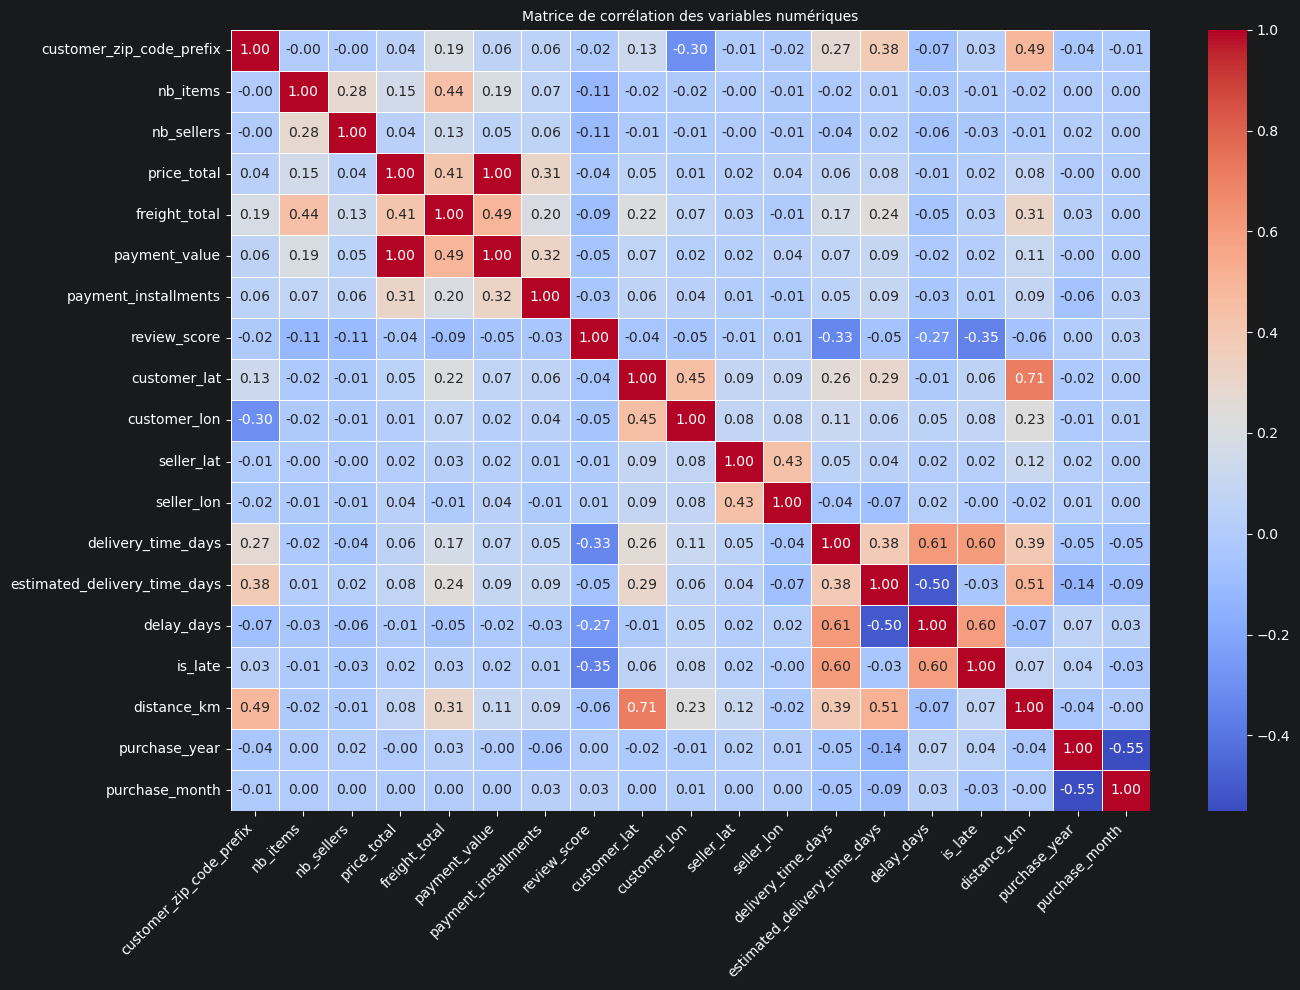

In [6]:
df_numeric = df.select_dtypes(include=["number"])
df_numeric = df_numeric.drop(columns=["has_review", "has_delivery_date"])

# Calcul de la matrice de corrélation
corr = df_numeric.corr()

# Plot
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Matrice de corrélation des variables numériques", fontsize=10)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

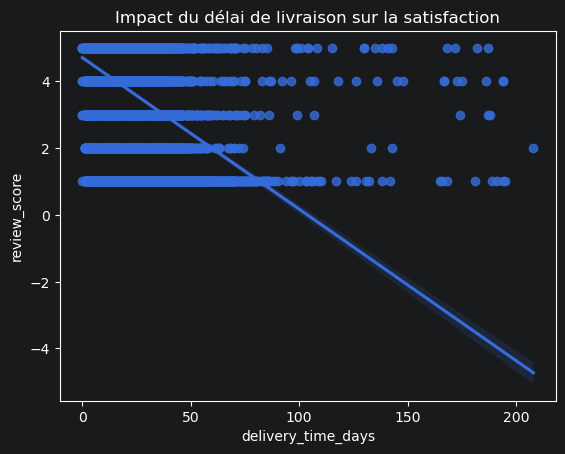

In [7]:
sns.regplot(x="delivery_time_days", y="review_score", data=df)
plt.title("Impact du délai de livraison sur la satisfaction")
plt.show()

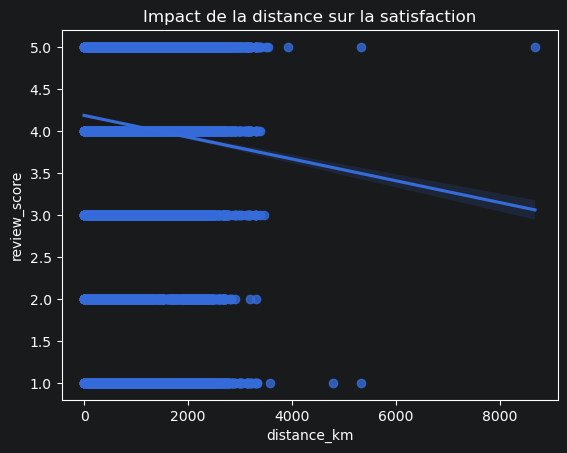

In [8]:
sns.regplot(x="distance_km", y="review_score", data=df)
plt.title("Impact de la distance sur la satisfaction")
plt.show()

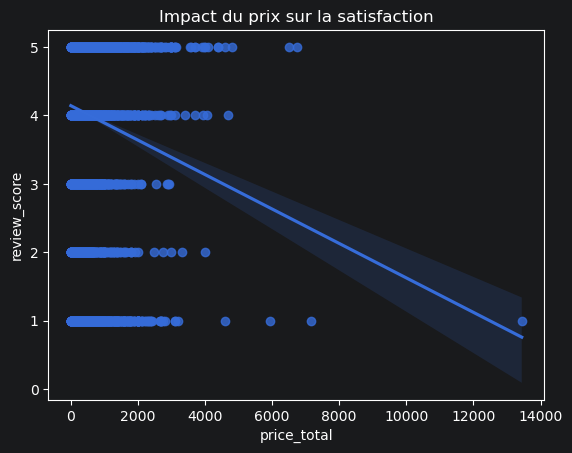

In [9]:
sns.regplot(x="price_total", y="review_score", data=df)
plt.title("Impact du prix sur la satisfaction")
plt.show()

In [10]:
df_model = df.copy()

df_model["target"] = (df_model["review_score"] >= 4).astype(int)

In [11]:
logit_model = smf.logit(
    formula="""
    target ~ delivery_time_days
    """,
    data=df_model,
)

logit_result = logit_model.fit()

print(logit_result.params)

Optimization terminated successfully.
         Current function value: 0.481160
         Iterations 6
Intercept             2.271819
delivery_time_days   -0.074066
dtype: float64


In [12]:
logit_model = smf.logit(
    formula="""
    target ~ delay_days
    """,
    data=df_model,
)

logit_result = logit_model.fit()

print(logit_result.params)

Optimization terminated successfully.
         Current function value: 0.493547
         Iterations 6
Intercept     0.643924
delay_days   -0.061054
dtype: float64


In [13]:
logit_model = smf.logit(
    formula="""
    target ~ is_late
    """,
    data=df_model,
)

logit_result = logit_model.fit()

print(logit_result.params)

Optimization terminated successfully.
         Current function value: 0.504800
         Iterations 5
Intercept    1.388462
is_late     -2.428950
dtype: float64


In [14]:
logit_model = smf.logit(
    formula="""
    target ~ price_total
    """,
    data=df_model,
)

logit_result = logit_model.fit()

print(logit_result.params)

Optimization terminated successfully.
         Current function value: 0.538957
         Iterations 5
Intercept      1.253301
price_total   -0.000323
dtype: float64


In [15]:
logit_model = smf.logit(
    formula="""
    target ~ nb_items
    """,
    data=df_model,
)

logit_result = logit_model.fit()

print(logit_result.params)

Optimization terminated successfully.
         Current function value: 0.534569
         Iterations 5
Intercept    1.677790
nb_items    -0.404072
dtype: float64


In [16]:
logit_model = smf.logit(
    formula="""
    target ~ delivery_time_days
           + delay_days
           + is_late
           + price_total
           + nb_items
    """,
    data=df_model,
)

logit_result = logit_model.fit()

print(logit_result.summary())
print(logit_result.params)

Optimization terminated successfully.
         Current function value: 0.461771
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                96476
Model:                          Logit   Df Residuals:                    96470
Method:                           MLE   Df Model:                            5
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                  0.1147
Time:                        08:46:47   Log-Likelihood:                -44550.
converged:                       True   LL-Null:                       -50323.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.5540      0.031     83.240      0.000       2.494       2.614
deliv

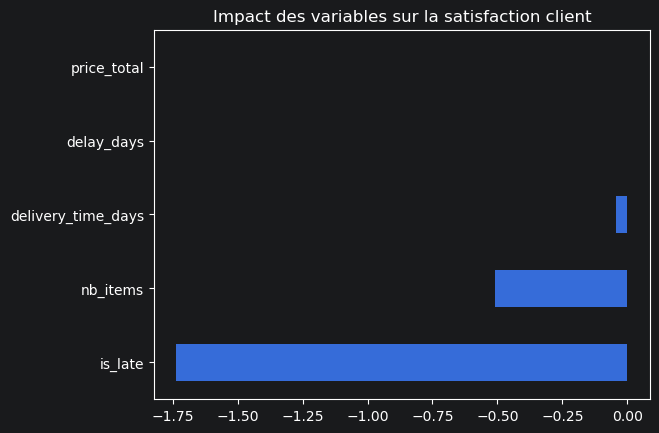

In [17]:
coef = logit_result.params.drop("Intercept")

coef.sort_values().plot(kind="barh")
plt.title("Impact des variables sur la satisfaction client")
plt.show()

In [20]:
features = [
    "delivery_time_days",
    "delay_days",
    "is_late",
    "price_total",
    "nb_items"
]

def partial_dependence_logit(model, df, feature, grid=None, n_points=100):
    base = df[features].mean().to_frame().T

    if grid is None:
        if df[feature].nunique() <= 5:
            grid = sorted(df[feature].dropna().unique())
        else:
            grid = np.linspace(
                df[feature].quantile(0.01),
                df[feature].quantile(0.99),
                n_points
            )

    rows = pd.concat([base] * len(grid), ignore_index=True)
    rows[feature] = grid

    preds = model.predict(rows)

    return pd.DataFrame({
        feature: grid,
        "predicted_probability": preds
    })

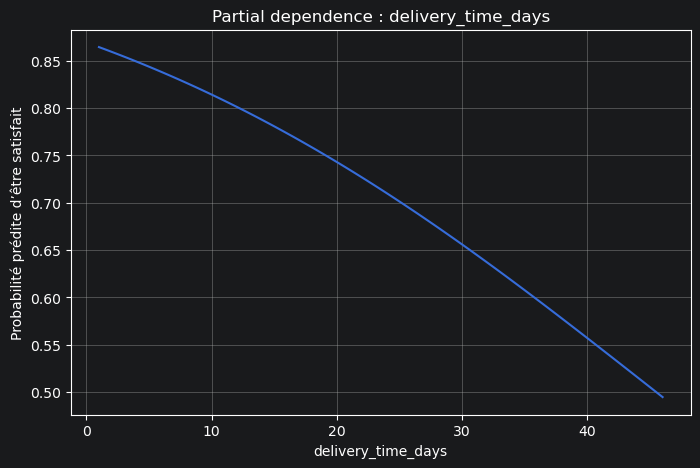

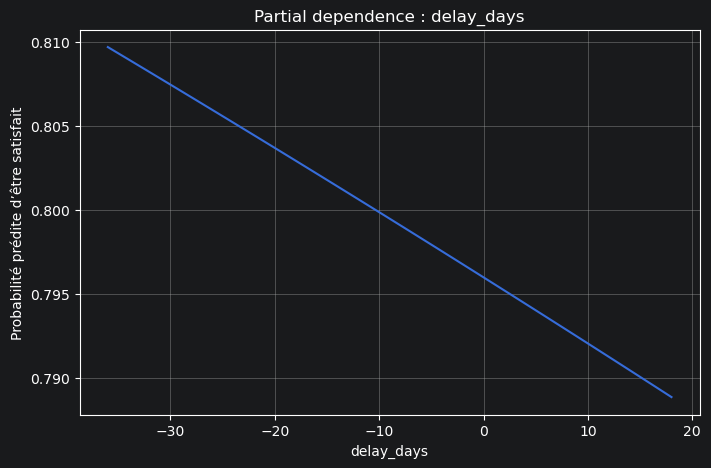

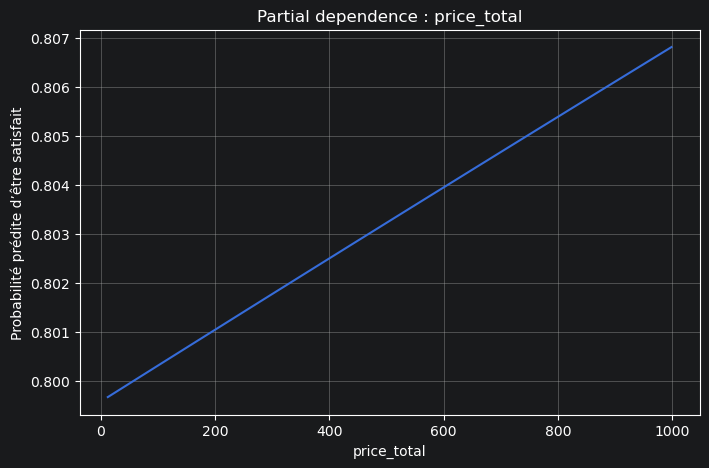

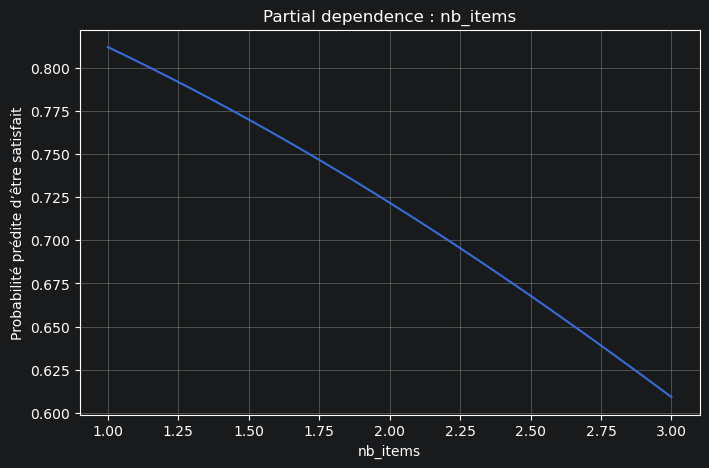

In [23]:
for feature in ["delivery_time_days", "delay_days", "price_total", "nb_items"]:
    pdp = partial_dependence_logit(logit_result, df_model, feature)

    plt.figure(figsize=(8, 5))
    plt.plot(pdp[feature], pdp["predicted_probability"])
    plt.title(f"Partial dependence : {feature}")
    plt.xlabel(feature)
    plt.ylabel("Probabilité prédite d’être satisfait")
    plt.grid(True)
    plt.show()

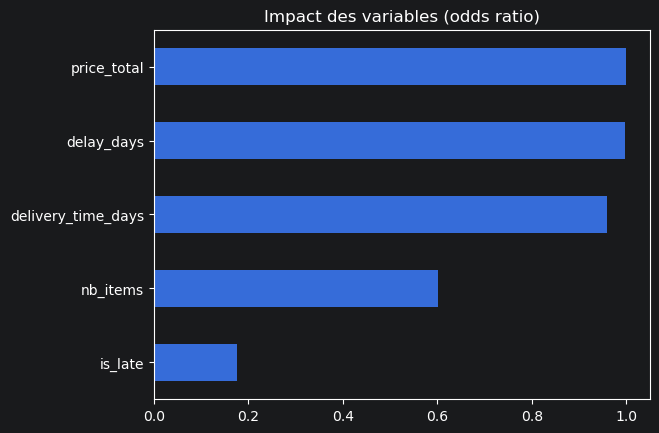

In [24]:
coef = logit_result.params.drop("Intercept")
odds = np.exp(coef)

odds.sort_values().plot(kind="barh")
plt.title("Impact des variables (odds ratio)")
plt.show()